<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week13_0530_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0530(금) 13주차 과제*\
*딥러닝 파이토치 교과서 7장 시계열 분석 - 05  p.393-417*

# 7.5 LSTM

RNN의 결정적 단점: \
가중치가 업데이트되는 과정에서 기울기가 1보다 작은 값이 계속 곱해지기 때문에 기울기가 사라지는 **기울기 소멸 문제** 발생.\
-> 이를 해결하기 위해 LSTM이나 GRU 사용

## 7.5.1 LSTM 구조

- 순전파
- 역전파

### 7.5.1.1 LSTM 순전파

LSTM은 기울기 소멸 문제를 해결하기 위해 **망각 게이트, 입력 게이트, 출력 게이트**를 은닉층의 각 뉴런에 추가함.

**망각 게이트**
- 과거 정보를 어느 정도 기억할지 결정함.
- 과거 정보$h_(t-1)$와 현재 데이터$x_t$를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해줌.
    - 시그모이드 출력값이 0: 과거 정보 버림
    - 시그모이드 출력값이 1: 과거 정보 보존

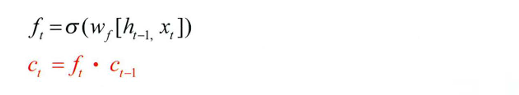

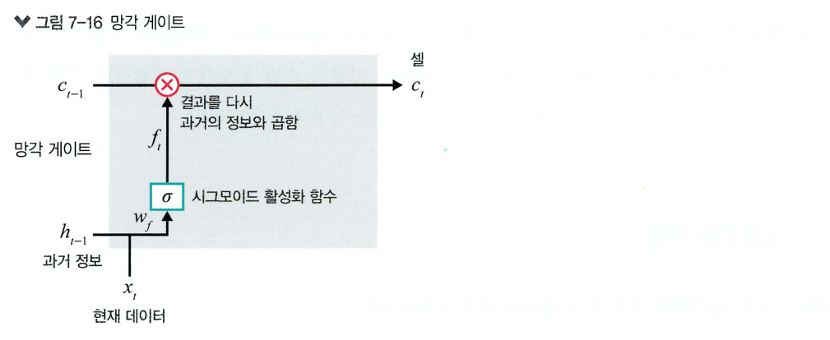

**입력 게이트**
- 현재 메모리에 새로운 정보를 반영할지 결정하는 역할.
- 과거 정보와 현재 데이터를 입력받아 시그모이드, 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량을 결정함.
    - 시그모이드, 하이퍼볼릭 탄젠트 출력값이 0:
    새로운 정보 차단
    - 시그모이드, 하이퍼볼릭 탄젠트 출력값이 1:
    새로운 정보 허용

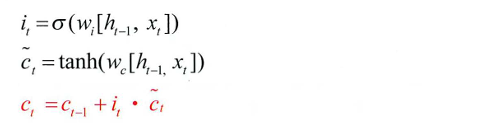

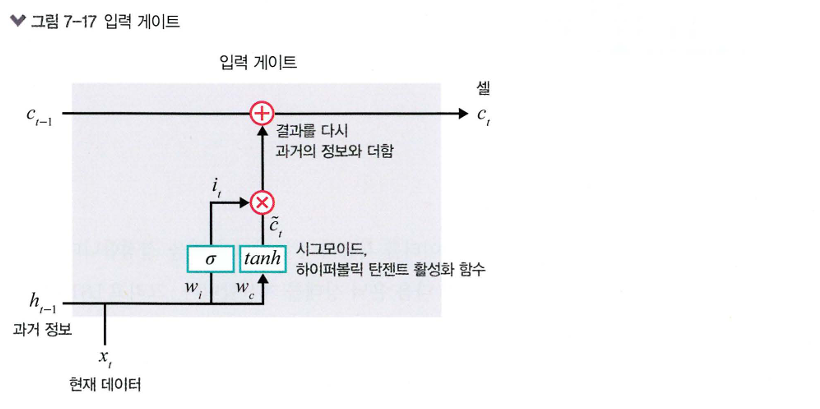

**셀**
- 각 단계에 대한 은닉 노드를 메모리 셀이라고 함.
- 총합을 사용하여 셀 값을 반영하며, 이것으로 기울기 소멸 문제가 해결됨.
- 셀을 업데이트하는 방법
    - 망각 게이트와 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태를 업데이트

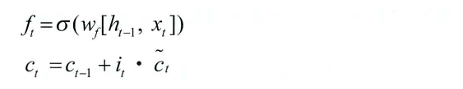

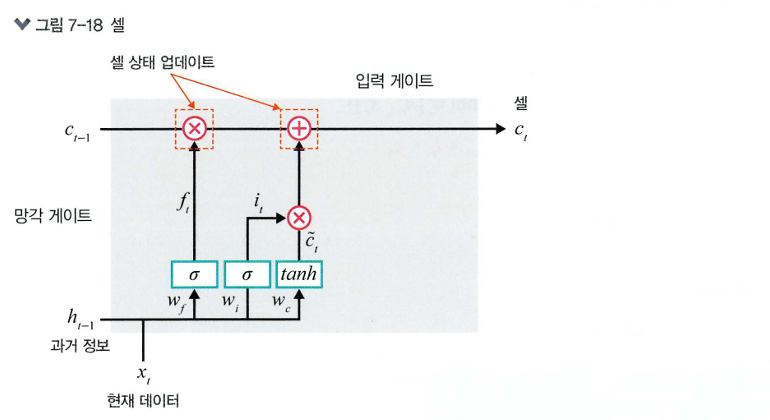

**출력 게이트**
- 과거 정보와 현재 데이터를 사용하여 뉴런의 출력을 결정함. \
    즉, 갱신된 메모리의 출력 값을 제어하는 역할.
- 이전 은닉 상태와 t번째 입력을 고려해서 다음 은닉 상태를 계산함. 그리고 LSTM에서는 이 은닉 상태가 그 시점에서의 출력이 됨.
    - 계산한 값이 1: 의미 있는 결과로 최종 출력
    - 계산한 값이 0: 해당 연산 출력을 하지 않음

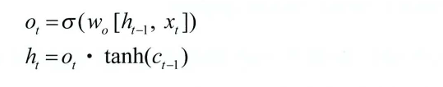

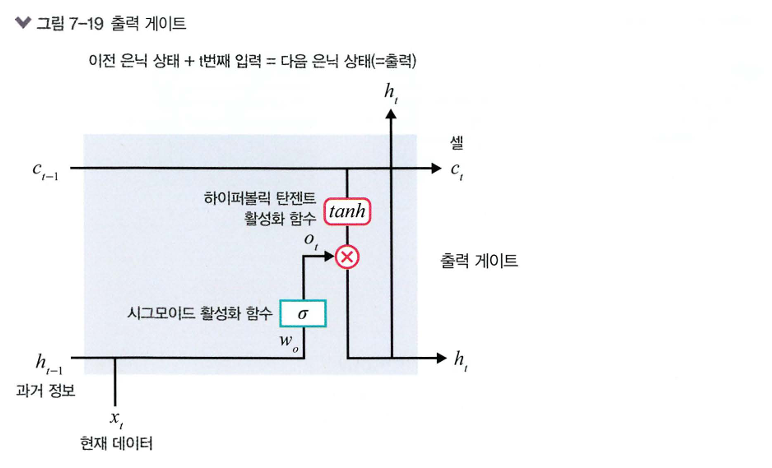

- LSTM 전체 게이트

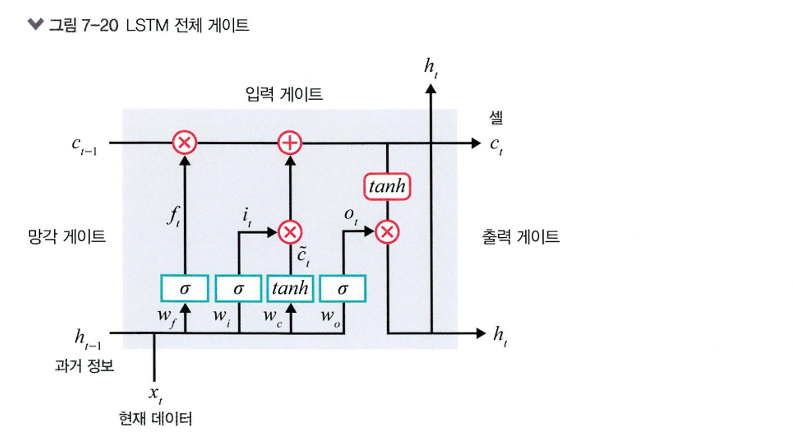

### 7.5.1.2 LSTM 역전파

LSTM은 셀을 통해서 역전파를 수행하기 때문에 '중단 없는 기울기' 라고도 함.

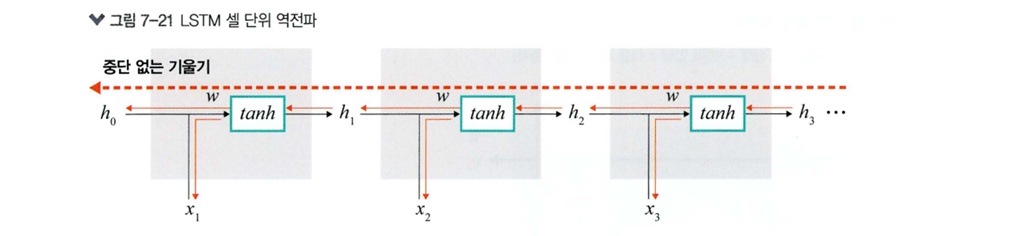

    최종 오차는 모든 노드에 전파되는데, 이때 셀을 통해서 중단 없이 전파됨

**역전파 수행 공식**

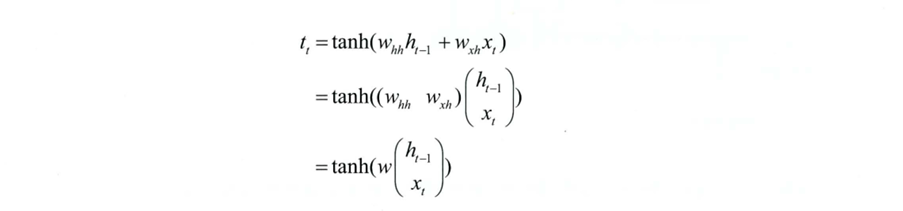

- 주의할 점
    - 셀 단위로 오차가 전파된다고 해서 입력 방향으로 오차가 전파되는 것은 아님
    - 셀 내부적으로는 오차가 입력으로 전파됨

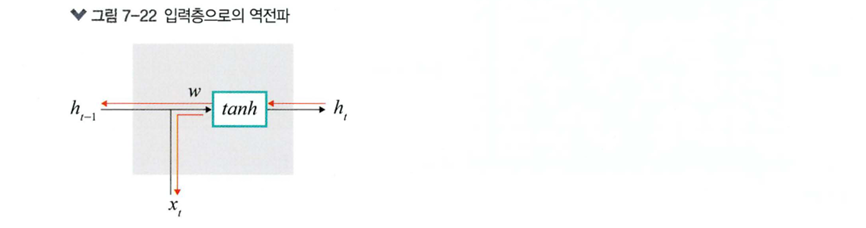

---

## 7.5.2 LSTM 셀 구현

**NOTE MNIST 데이터**
- 훈련 데이터셋 6만 개와 검증 데이터셋 1만 개로 구성됨.
- 손으로 쓴 숫자 이미지(0에서 9까지 값을 갖는 고정 크기 이미지(28
x28 픽셀))들로 구성되어 있음

In [1]:
# 코드 7-29 라이브러리 호출

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter # ------ 파라미터 목록을 갖고 있는 라이브러리(패키지)
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math # ------ 수학과 관련되어 다양한 함수들과 상수들이 정의되어 있는 라이브러리

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False # GPU 사용에 필요

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor # GPU 사용에 필요

torch.manual_seed(125) # ------ 랜덤 시드 고정
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [2]:
# 코드 7-30 데이터 전처리

import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,)) # ------평균을 0.5, 표준편차를 1.0으로 데이터 정규화
])

In [3]:
# 코드 7-31 데이터셋 내려받기

from torchvision.datasets import MNIST
download_root = '../chap07/MNIST_DATASET' # •••••. MNIST를 내려받을 경로
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.67MB/s]


In [4]:
# 코드 7-32 데이터셋을 메모리로 가져오기

batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

In [5]:
# 코드 7-33 변수 값 지정

batch_size = 100
n_iters = 6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

In [6]:
# 코드 7-34 LSTM 셀 네트워크 구축

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias)  # (1)
        self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=bias) # (1)'
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)                                # (2)

    def forward(self, x, hidden):
        hx, cx = hidden
        x = x.view(-1, x.size(1))

        gates = self.x2h(x) + self.h2h(hx)                            # (1)''
        gates = gates.squeeze()                                       # (3)
        ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)     # (1)'''

        ingate = F.sigmoid(ingate)
        forgetgate = F.sigmoid(forgetgate)
        cellgate = F.tanh(cellgate)
        outgate = F.sigmoid(outgate)

        cy = torch.mul(cx, forgetgate) + torch.mul(ingate, cellgate)  # (4)
        hy = torch.mul(outgate, F.tanh(cy))                           # (4)'

        return (hy, cy)

> #(1) & (1)' \
    왜 은닉층의 뉴런/유닛에 4를 곱할까?

- self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias)와 \
self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=bias)에서 \
4 * hidden_size가 사용되고 있는 이유

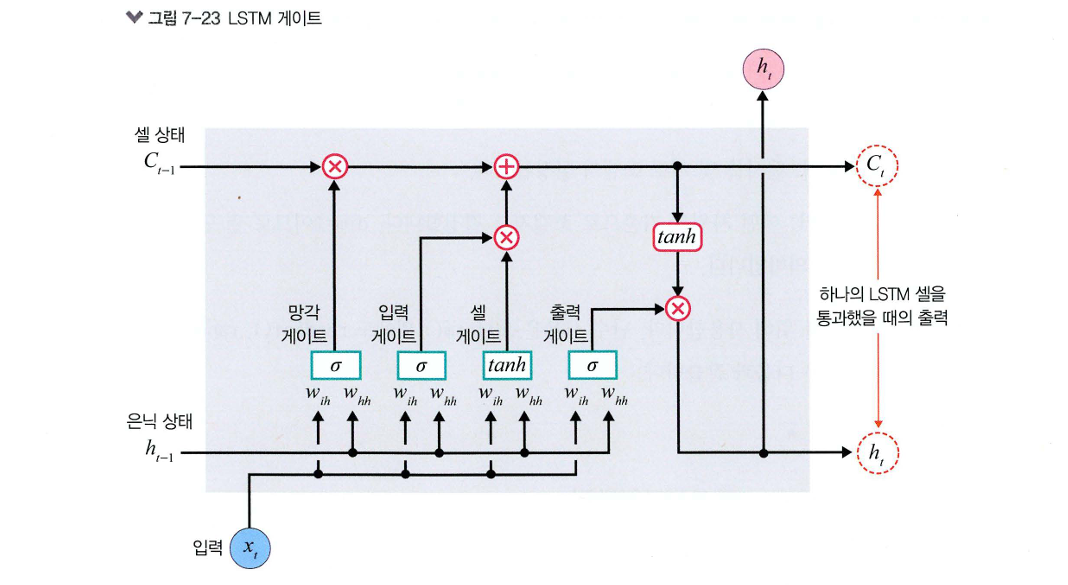

- 게이트
    - 망각
    - 입력
    - 셀
    - 출력
    
    으로 구성되며 모든 게이트는 (1)"처럼 구할 수 있음.

- (1)'' 풀어서 살펴보기

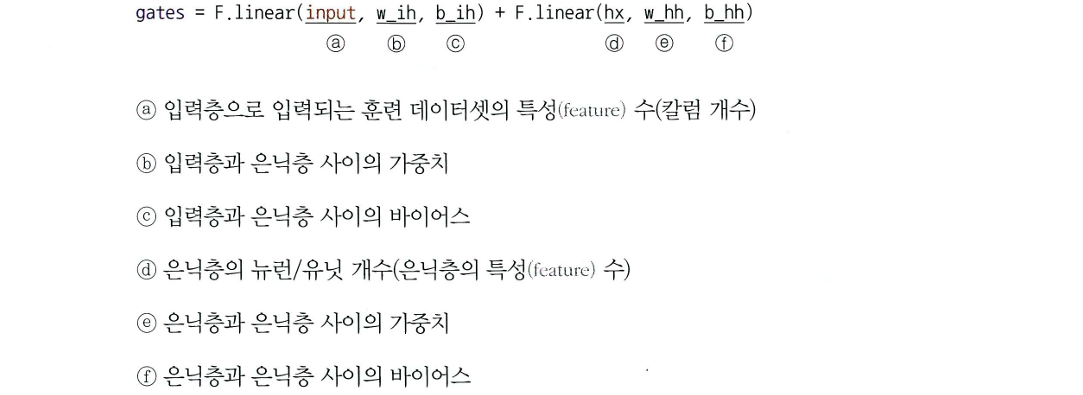

> #(1)'''

- 이렇게 계산된 게이트는 (1)'''처럼 gates.chunk(4, 1)에 의해 네 개로 쪼개져서 각각 망각, 입력, 셀, 출력 게이트를 의미하는 변수에 저장됨. (즉, gates가 네 개로 쪼개지는 상황이기 때문에 4가 곱해졌던 것) 일반적으로 바이어스도 4를 곱해 주지만 예제에서는 은닉층의 뉴런/유닛 개수만 4를 곱함.

- torch.chunk() 사용방법

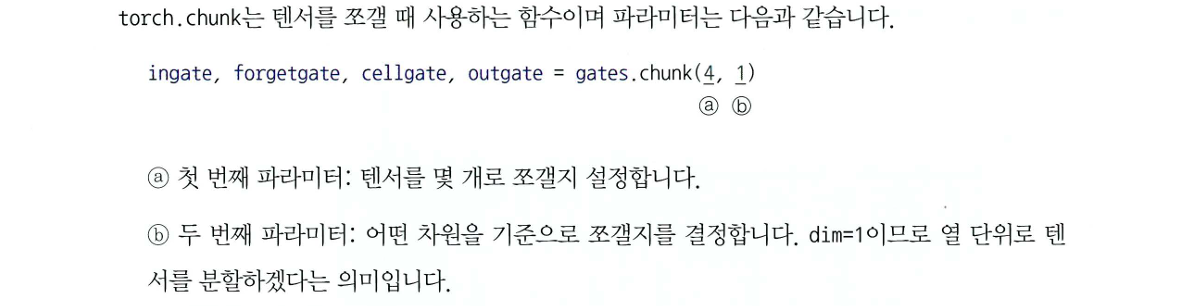

> #(2) \
uniform()

- uniform()은 난수를 위해 사용함.
- 난수 사용: uniform() 외에도 randint(), random() 등

- 사용 방법

In [7]:
from random import *

ri = randint(1, 10) #------1부터 10 사이의 임의의 정수
print(ri)

rd = random() #------0부터 1 사이의 임의의 실수(float)
print (rd)

ui = uniform(1, 10) #------ 1부터 10 사이의 임의의 실수(float)
print(ui)

rr = randrange(1, 10, 2) #------1부터 10 사이를 2씩 건너띈 임의의 정수(ex. 1,3,5,7,9)
print(rr)

2
0.4025432714776819
4.052025808880521
5


> #(3) \
torch.squeeze()

- torch.squeeze()는 텐서의 차원을 줄일 때 사용함.
- 사용 방법

In [8]:
import torch

x = torch.FloatTensor([[1], [2]]) #------(2x1) 크기의 2차원 텐서 생성
print(x)
print(x.shape)
print('--squeeze 적용--')
print (x.squeeze()) #------ squeeze()가 적용되어 1차원으로 축소
print(x.squeeze().shape)

tensor([[1.],
        [2.]])
torch.Size([2, 1])
--squeeze 적용--
tensor([1., 2.])
torch.Size([2])


    -> (2 x 1) 텐서가 (2,) 크기를 갖는 1차원 벡터로 변경됨

> #(4), (4)'

- 하나의 LSTM 셀을 통과하면 셀 상태와 은닉 상태가 출력으로 주어짐. 이때 셀 상태는 입력, 망각, 셀 게이트에 의해 계산되며 은닉 상태는 출력 게이트에 의해 계산됨. 여기에서 사용되는 torch.mul()은 텐서에 곱셈을 할 때 사용함.
- 사용 방법

In [9]:
import torch

x = torch.FloatTensor([[1], [2]]) #------ 임의의 텐서 생성
print(x)

print('--mul 적용--')
torch.mul(x, 3) #------x라는 텐서의 원소에 3을 곱함

tensor([[1.],
        [2.]])
--mul 적용--


tensor([[3.],
        [6.]])

---

In [10]:
# 코드 7-35 LSTM 셀의 전반적인 네트워크

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim # ------ 은닉층의 뉴런/유닛 개수

        self.layer_dim = layer_dim
        self.lstm = LSTMCell(input_dim, hidden_dim, layer_dim)  # (1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if torch.cuda.is_available():
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

        if torch.cuda.is_available():
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0), hidden_dim))

        outs = []
        cn = c0[0, :, :]
        hn = h0[0, :, :]

        for seq in range(x.size(1)):
            hn, cn = self.lstm(x[:, seq, :], (hn, cn))
            outs.append(hn)

        out = outs[-1].squeeze()
        out = self.fc(out)
        return out

> #(1)

- LSTM 셀은 앞에서 정의한 함수를 불러오는 부분
- 파라미터는 다음과 같음

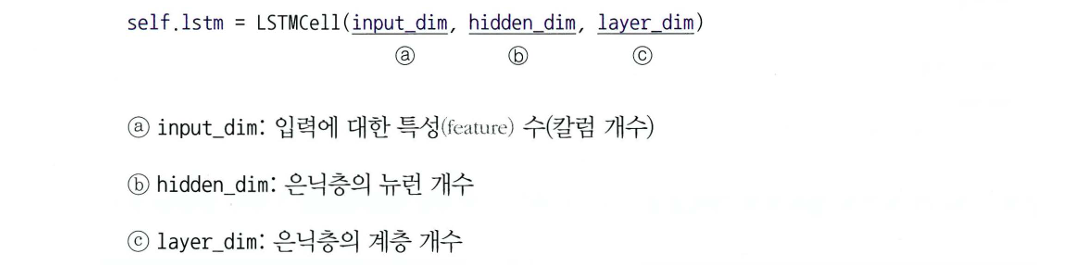

---

In [11]:
# 코드 7-36 옵티마이저와 손실 함수 지정

input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available():
    model.cuda()

criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

---

In [12]:
# 코드 7-37 모델 학습 및 성능 확인

seq_dim = 28
loss_list = []
iter = 0

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda()) # (1)
            labels = Variable(labels.cuda())
        else:
            images = Variable(images.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0
            for images, labels in valid_loader:

                if torch.cuda.is_available():
                    images = Variable(images.view(-1, seq_dim, input_dim).cuda())

                else:
                    images = Variable(images.view(-1, seq_dim, input_dim))

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct / total
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 2.237457513809204. Accuracy: 21.420000076293945
Iteration: 1000. Loss: 0.8865489363670349. Accuracy: 75.66000366210938
Iteration: 1500. Loss: 0.36925092339515686. Accuracy: 89.68000030517578
Iteration: 2000. Loss: 0.22741778194904327. Accuracy: 93.22000122070312
Iteration: 2500. Loss: 0.04691021144390106. Accuracy: 95.62999725341797
Iteration: 3000. Loss: 0.05541188269853592. Accuracy: 95.95999908447266
Iteration: 3500. Loss: 0.08951079845428467. Accuracy: 96.51000213623047
Iteration: 4000. Loss: 0.02204427309334278. Accuracy: 96.95999908447266
Iteration: 4500. Loss: 0.07599193602800369. Accuracy: 96.76000213623047
Iteration: 5000. Loss: 0.05491260439157486. Accuracy: 97.11000061035156
Iteration: 5500. Loss: 0.16436734795570374. Accuracy: 96.5199966430664
Iteration: 6000. Loss: 0.01572381891310215. Accuracy: 97.20999908447266
Iteration: 6500. Loss: 0.01401564758270979. Accuracy: 97.88999938964844
Iteration: 7000. Loss: 0.01943875104188919. Accuracy: 97.91999816894

    -> 정확도가 97%로 상당히 높음

> #(1)

현재 버전에서는 모든 텐서가 자동으로 Variable의 성질을 갖기 때문에 torch.autograd.Variable을 사용할 필요가 없지만 학습/연습 및 이전 버전에서 구현된 파이토치 코드를 이해하기 위해 사용함.

In [13]:
# 코드 7-38 테스트 데이터셋을 이용한 모델 예측 성능 확인

def evaluate(model, val_iter):
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter:
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
        else:
            images = Variable(images.view(-1, seq_dim, input_dim)).to(device)

        logit = model(images).to(device)
        loss = F.cross_entropy(logit, labels, reduction='sum')
        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / len(val_iter.dataset)
    return avg_loss, avg_accuracy

---

In [14]:
# 코드 7-39 모델 예측 성능 확인

test_loss, test_acc = evaluate(model, test_loader)
print('Test Loss: %5.2f | Test Accuracy: %5.2f' % (test_loss, test_acc))

Test Loss:  0.07 | Test Accuracy:  0.98


    IMDB에서 MNIST로 데이터셋이 바뀌기는 했지만 98%로 성능이 매우 좋음.\

    IMDB는 사전에 전처리가 되지 않은 데이터셋이고 MNIST는 사전에 전처리가 된 상태의 데이터셋이기 때문에 정확도 측면에서 차이가 날 수 있음. 이와 같이 사전에 전처리가 되지 않은 데이터셋의 경우 정확도를 높이기 위해 은닉층의 개수(혹은 뉴런의 개수) 및 하이퍼파라미터 수정 등이 필요함.

---
---

## 7.5.3 LSTM 계층 구현

 스타벅스 주가 데이터셋-모델이 얼마나 주가 예측을 잘 하는지

In [15]:
# 코드 7-40 라이브러리 호출

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
# 코드 7-41 데이터셋 가져오기

# 1) raw.githubusercontent.com 주소로 변경
url = 'https://raw.githubusercontent.com/gilbutITbook/080289/main/chap07/data/SBUX.csv'

# 2) pandas로 읽어서 변수 data에 저장
data = pd.read_csv(url)

print(data .dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [17]:
# 코드 7-42 날짜 칼럼을 인덱스로 사용

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [18]:
# 코드 7-43 데이터 형식 변경 (정수->실수)

data['Volume'] = data['Volume'].astype(float)

~ 전처리 완료 ~

In [19]:
# 코드 7-44 훈련과 레이블 분리

X = data.iloc[:, :-1]
y = data.iloc[:, 5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [20]:
# 코드 7-45 데이터 분포 조정

ms = MinMaxScaler()
ss = StandardScaler()

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape", X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


    -> 훈련 데이터셋은 200개의 데이터와 다섯 개의 칼럼으로 구성되어 있으며, 테스트 데이터셋(y_test)은 53개의 데이터와 한 개의 칼럼으로 구성되어 있는 것을 확인할 수 있음.

In [21]:
# 코드 7-46 데이터셋의 형태 및 크기 조정

X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors,   (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors,  (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


> #(1) \
torch.reshape: 텐서의 형태를 바꿀 때 사용.

In [22]:
# 코드 7-47 LSTM 네트워크

class LSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM, self).__init__()
        self.num_classes = num_classes # 클래스 개수
        self.num_layers = num_layers # LSTM 계층의 개수
        self.input_size = input_size # 입력 크기로 훈련 데이터셋의 칼럼 개수 의미
        self.hidden_size = hidden_size # 은닉층의 뉴런 개수
        self.seq_length = seq_length # 시퀀스 길이

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc_1 =  nn.Linear(hidden_size, 128) # 완전연결층
        self.fc = nn.Linear(128, num_classes) # 출력층

        self.relu = nn.ReLU()

    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉 상태를 0으로 초기화
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 셀 상태를 0으로 초기화

        output, (hn, cn) = self.lstm(x, (h_0, c_0)) # LSTM 계층에 은닉 상태와 셀 상태 적용
        hn = hn.view(-1, self.hidden_size) # 완전연결층 적용을 위해 데이터의 형태 조정
        out = self.relu(hn)
        out = self.fc_1(out)
        out = self.relu(out)
        out = self.fc(out)
        return out

In [23]:
# 코드 7-48 변수 값 설정

num_epochs = 1000 # 1000번의 에포크
learning_rate = 0.0001 # 학습률을 0.0001로 지정

input_size = 5 # 입력 데이터셋의 칼럼 개수
hidden_size = 2 # 은닉층의 뉴런/유닛 개수
num_layers = 1 # LSTM 계층의 개수

num_classes = 1 # 클래스 개수
model = LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1]) # 앞에서 정의한 값들을 이용하여 LSTM 모델 학습

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [24]:
# 코드 7-49 모델 학습

for epoch in range(num_epochs):
    outputs = model.forward(X_train_tensors_f)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensors)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print('Epoch : %d, loss : %1.5f' % (epoch, loss.item()))

Epoch : 0, loss : 0.18287
Epoch : 100, loss : 0.05713
Epoch : 200, loss : 0.03855
Epoch : 300, loss : 0.03717
Epoch : 400, loss : 0.03599
Epoch : 500, loss : 0.03326
Epoch : 600, loss : 0.02937
Epoch : 700, loss : 0.02517
Epoch : 800, loss : 0.02214
Epoch : 900, loss : 0.02038


- 예측 결과를 시각적으로 표현

In [25]:
# 코드 7-50 모델 예측 결과를 출력하기 위한 데이터 크기 재구성

df_x_ss = ss.transform(data.iloc[:, :-1])
df_y_ms = ms.transform(data.iloc[:, -1:])

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

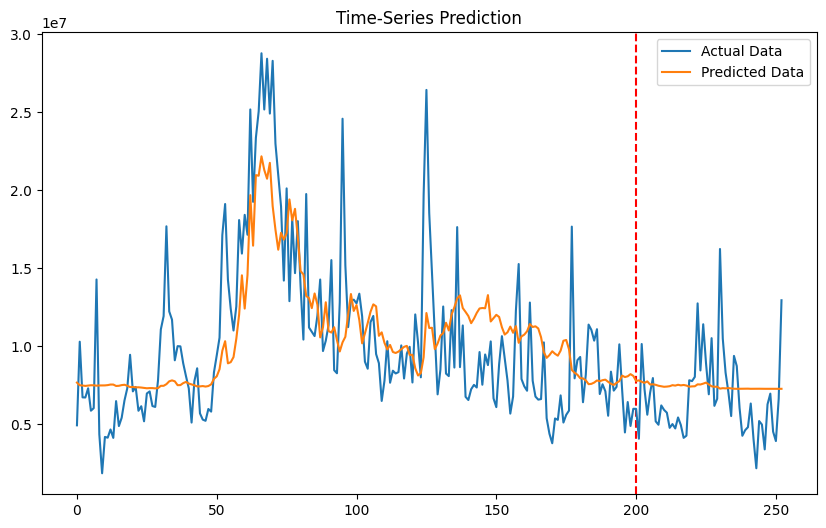

In [26]:
# 코드 7-51 모델 예측 결과 출력

train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted= ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c='r', linestyle='--')    # (1)

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

> #(1) \
axvline()


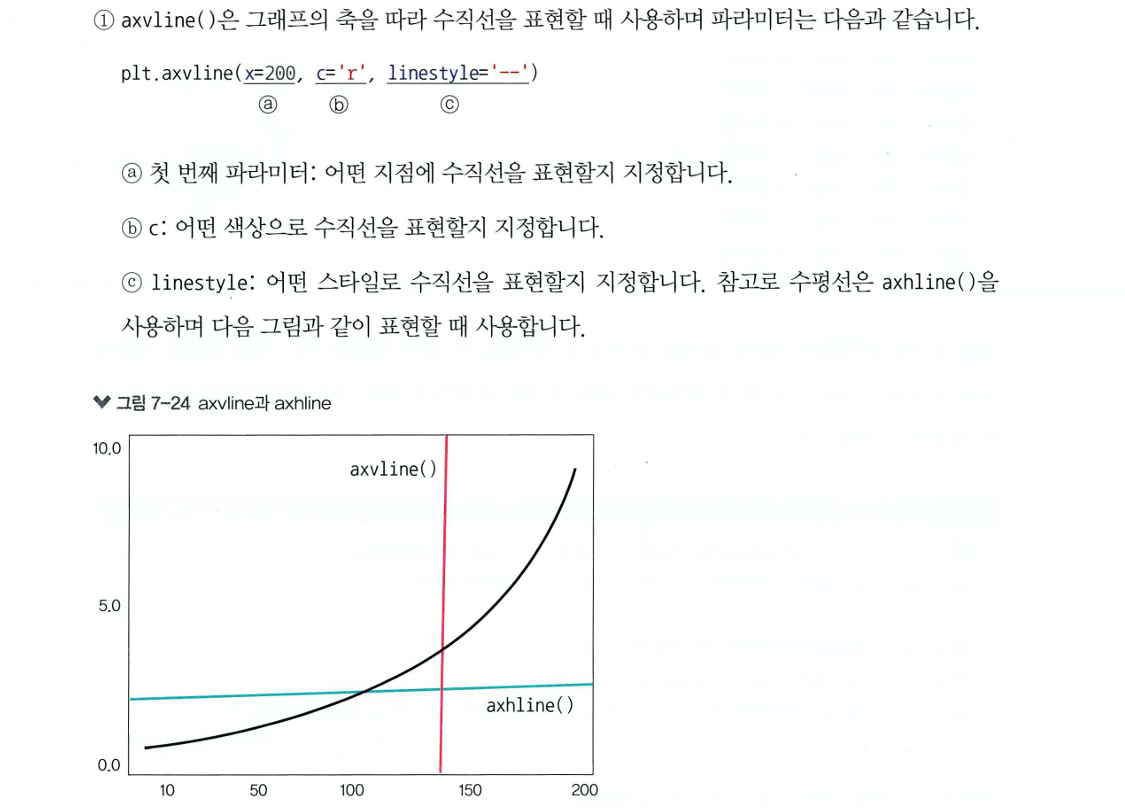

    파란색: 실제 레이블에 대한 출력 결과
    
    주황색: 모델이 예측한 결과
    
    이와 같이 결과가 만족스럽지 않다면 하이퍼파라미터에 대한 튜닝도 중요하지만 모델을 변경해 보는 것이 좋음.